### 0. Importaciones

In [3]:
# pip install scikit-learn xgboost
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Carga de Datasets

In [4]:
# Ajustar la ruta del archivo
from pathlib import Path

ROOT = Path().resolve().parents[0]
FOLDER_PATH = ROOT / "data" / "training_data"

workers = pd.read_csv(FOLDER_PATH / "workers.csv")
company = pd.read_csv(FOLDER_PATH / "company.csv", parse_dates=["start_date"])
survey  = pd.read_csv(FOLDER_PATH / "answers_survey.csv")

print(f"Workers: {workers.shape}")
print(f"Company: {company.shape}")
print(f"Survey:  {survey.shape}")

Workers: (10000, 9)
Company: (10000, 8)
Survey:  (10000, 28)


### 2. Merge de Datasets

In [5]:
df = workers.merge(company, left_on="id", right_on="id_worker") \
            .merge(survey,  on="id_worker")

print(f"Dataset unido: {df.shape}")
df.head(3)

Dataset unido: (10000, 44)


,id,name,last_names,age,gender,group_index,rank_index,id_group,id_rank,id_worker,...,q18,q19,q20,q21,avg_agotamiento,avg_despersonalizacion,avg_eficacia,eficacia_invertida,burnout_score,burnout_risk
0,9427c2a4-5b2e-4890-b213-d16b057ecb49,Javier,Valderrama López,26,Masculino,70,6,11a72847-5947-4e40-9f72-57b364432cf1,a7ea8107-f687-4d1b-a6db-c6092e0e1540,9427c2a4-5b2e-4890-b213-d16b057ecb49,...,4,4,4,4,1.86,1.57,4.43,1.57,0.1431,Muy Bajo
1,a6fdfa37-e8cc-43d2-bcb8-38ed5dd6e2f8,John,Barrera Ocampo,33,Masculino,160,4,dfb4fae3-0a3a-4385-bd33-f5139fca9ef3,6f28c950-c4b3-4a09-b6fa-86eff39dbc8b,a6fdfa37-e8cc-43d2-bcb8-38ed5dd6e2f8,...,4,4,4,5,2.00,2.00,4.29,1.71,0.2821,Bajo
2,a71fc647-4cfe-473b-8db9-a313e89e7693,Julia,Castro Sánchez,25,Femenino,240,6,1e02e925-2850-4183-8084-d624ba65a97b,a7ea8107-f687-4d1b-a6db-c6092e0e1540,a71fc647-4cfe-473b-8db9-a313e89e7693,...,5,5,3,5,1.57,1.57,4.43,1.57,0.1516,Muy Bajo


### 3. Transformación de Datos
#### Nuevas Columnas
Crear nuevas columnas derivadas de las que ya están 

In [6]:
# Antigüedad en años desde la fecha de ingreso
hoy = pd.Timestamp("2026-05-02")
df["seniority_years"] = ((hoy - df["start_date"]).dt.days / 365).round(1)

# Tasa de completitud de tareas
df["completion_rate"] = (df["completed_tasks"] / df["assigned_tasks"].replace(0, np.nan)).round(3)

print("Nuevas features:")
print(df[["seniority_years", "completion_rate"]].describe().T.round(2))

Nuevas features:
                   count  mean   std  min   25%   50%    75%   max
seniority_years  10000.0  7.85  3.19  2.3  5.10  7.80  10.70  13.3
completion_rate  10000.0  0.70  0.16  0.2  0.58  0.71   0.81   1.0


#### Label Encoding
Convertir variables categóricas de texto en números enteros únicos

In [7]:
# Inicializar encoder de sklearn
le = LabelEncoder()

df["gender_enc"] = le.fit_transform(df["gender"])
df["work_mode_enc"] = le.fit_transform(df["work_mode"])
df["location_enc"]  = le.fit_transform(df["location"])

# Verificar el mapeo para saber qué número corresponde a qué categoría
for col, enc_col in [("gender","gender_enc"), ("work_mode","work_mode_enc"), ("location","location_enc")]:
    mapeo = dict(zip(df[col], df[enc_col]))
    print(f"{col}: {mapeo}")

gender: {'Masculino': 1, 'Femenino': 0, 'Prefiero no decir': 3, 'No binario': 2}
work_mode: {'Remota': 1, 'Híbrida': 0}
location: {'Bogotá': 0, 'Cartagena': 2, 'Medellín': 3, 'Cali': 1, 'Pereira': 4}


In [8]:
print(df.columns)

Index(['id', 'name', 'last_names', 'age', 'gender', 'group_index',
       'rank_index', 'id_group', 'id_rank', 'id_worker', 'assigned_tasks',
       'completed_tasks', 'absences', 'employee_calls', 'work_mode',
       'location', 'start_date', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7',
       'q8', 'q9', 'q10', 'q11', 'q12', 'q13', 'q14', 'q15', 'q16', 'q17',
       'q18', 'q19', 'q20', 'q21', 'avg_agotamiento', 'avg_despersonalizacion',
       'avg_eficacia', 'eficacia_invertida', 'burnout_score', 'burnout_risk',
       'seniority_years', 'completion_rate', 'gender_enc', 'work_mode_enc',
       'location_enc'],
      dtype='str')


### 4. Seleccionar los Features
No todas las columnas son útiles, por lo que solo hay que elegir las variables que tienen relación con el burnout.

In [9]:
# Variables predictoras o a usar en el modelo (X)
FEATURES = [
    # Datos laborales
    "assigned_tasks", "completed_tasks", "absences", 
    "employee_calls", "completion_rate", "seniority_years",
    "rank_index", "group_index",
    # Datos personales
    "age", "gender_enc", 
    # Modalidad y sede
    "work_mode_enc", "location_enc",
    # Encuesta MBI-GS
    "avg_agotamiento", "avg_despersonalizacion", "eficacia_invertida"
]

X = df[FEATURES] # Variables independientes o predictoras
y = df["burnout_risk"] # Variable dependente o a predecir

print(f"Features: {X.shape}")
print(f"Clases: {y.unique()}")
print(f"\nBalance de clases:")
print(y.value_counts()) # Cuantos casos hay de cada clase

Features: (10000, 15)
Clases: <StringArray>
['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Moderado']
Length: 5, dtype: str

Balance de clases:
burnout_risk
Bajo        3000
Medio       2500
Muy Bajo    2000
Moderado    1500
Alto        1000
Name: count, dtype: int64


### 5. Dividir Dataset 
Separar dataset en dos partes, el 80% para entrenar el modelo y el otro 20% para evaluar

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, # 20% para test, 80% para train
    random_state=42, # seed used by the random numer generator
    stratify=y # asegura que la proporción de clases se mantenga en ambos sets
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nBalance en train:")
print(y_train.value_counts())
print(f"\nBalance en test:")
print(y_test.value_counts())

Train: (8000, 15) | Test: (2000, 15)

Balance en train:
burnout_risk
Bajo        2400
Medio       2000
Muy Bajo    1600
Moderado    1200
Alto         800
Name: count, dtype: int64

Balance en test:
burnout_risk
Bajo        600
Medio       500
Muy Bajo    400
Moderado    300
Alto        200
Name: count, dtype: int64


### 6. Entrenar los modelos

In [11]:
# Árbol de decisión
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
# XGBoost
# Encodar la variable objetivo porque XGBoost no maneja etiquetas de texto
y_train_enc = le.fit_transform(y_train) # Aprende parametros y transforma la data

# XGBClassifier es la versión para clasificación de XGBoost, n_estimators es el número de árboles a construir, eval_metric es la métrica de evaluación (mlogloss para multiclases)
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, 
                              eval_metric="mlogloss") # mlogloss porque es multiclases 
xgb_model.fit(X_train, y_train_enc)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### 7. Evaluar los Modelos
Medir qué tan bien predice cada modelo con los datos de test

In [13]:
# Predicciones
y_pred_dt  = dt.predict(X_test)
y_pred_rf  = rf.predict(X_test)
y_pred_xgb = le.inverse_transform(xgb_model.predict(X_test))

# Accuracy de cada modelo
print(f"Árbol de Decisión : {accuracy_score(y_test, y_pred_dt)*100:.2f} %")
print(f"Random Forest     : {accuracy_score(y_test, y_pred_rf)*100:.2f} %")
print(f"XGBoost           : {accuracy_score(y_test, y_pred_xgb)*100:.2f} %")

Árbol de Decisión : 89.20 %
Random Forest     : 93.80 %
XGBoost           : 92.90 %


El modelo "Random Forest" fue el que obtuvo una mayor exactitud, por lo tanto, se genera un reporte más detallado

In [14]:
# Reporte detallado del mejor (Random Forest)
print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))


Random Forest
              precision    recall  f1-score   support

        Alto       0.95      0.97      0.96       200
        Bajo       0.92      0.94      0.93       600
       Medio       0.93      0.92      0.92       500
    Moderado       0.94      0.92      0.93       300
    Muy Bajo       0.97      0.95      0.96       400

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



### 8. Matriz de Confusión
Muestra dónde se equivoca el modelo.
- Las filas son la categoría real del empleado, mientras las columnas son lo que el modelo predijo.
- Los números de la diagonal son los aciertos.
- Los números fuera de la diagonal son los errores.

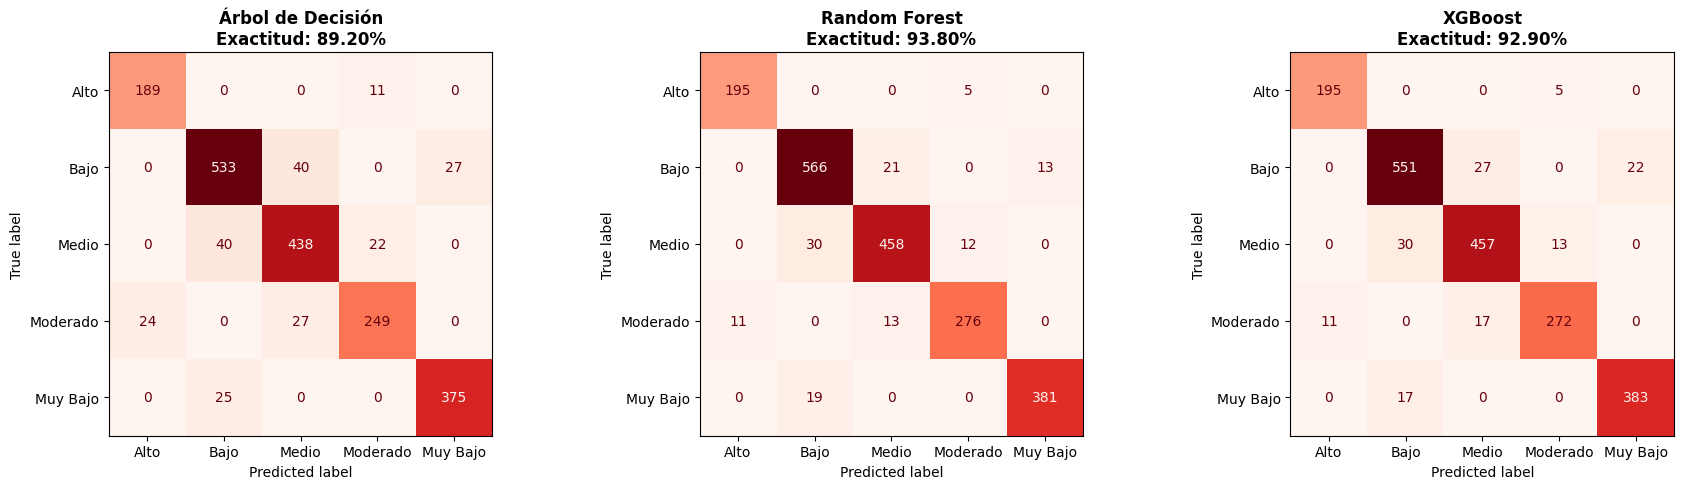

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model, preds, title in zip(
    axes,
    [dt, rf, xgb_model],
    [y_pred_dt, y_pred_rf, y_pred_xgb],
    ["Árbol de Decisión", "Random Forest", "XGBoost"]
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        ax=ax,
        colorbar=False,
        cmap="Reds"
    )
    ax.set_title(f"{title}\nExactitud: {accuracy_score(y_test, preds):.2%}", fontweight="bold")

plt.tight_layout()
plt.show()

Ningún modelo confunde "Alto" con "Muy bajo", ni viceversa, por lo que no se presentan errores graves. 
Los errores más comunes en todos los modelos fueron:
- Confusión entre "Bajo" (predicted) y "Medio" (true), es el error más frecuente, subestima ligeramente el riesgo.
- Confusión entre "Medio" (predicted) y "Bajo" (true), es de los errores más frecuentes, sobreestima ligeramente el riesgo.
- Confusión entre "Alto" (predicted) y "Moderado" (true).
- Confusión entre "Bajo" (predicted) y "Muy bajo" (true), y viceversa, son errores tolerable.
- Confusión entre "Medio" y "Moderado", y viceversa.
- Confusión entre "Moderado" y "Alto", de las categorías que confunde, esta es la que tiene menos errores.
Todos los modelos cometieron errores entre las mismas categorías, fue cuestión de cual cometió menos errores.

Los errores ocurren entre categorías adyacentes, lo que se podría esperar y es aceptable según el modelo MBI-GS. Ningún modelo cometó errores graves en los extremos.

### 9. Importancia de Features del Random Forest
Mostrar qué variables fueron más determinantes para que el modelo tome las decisiones.

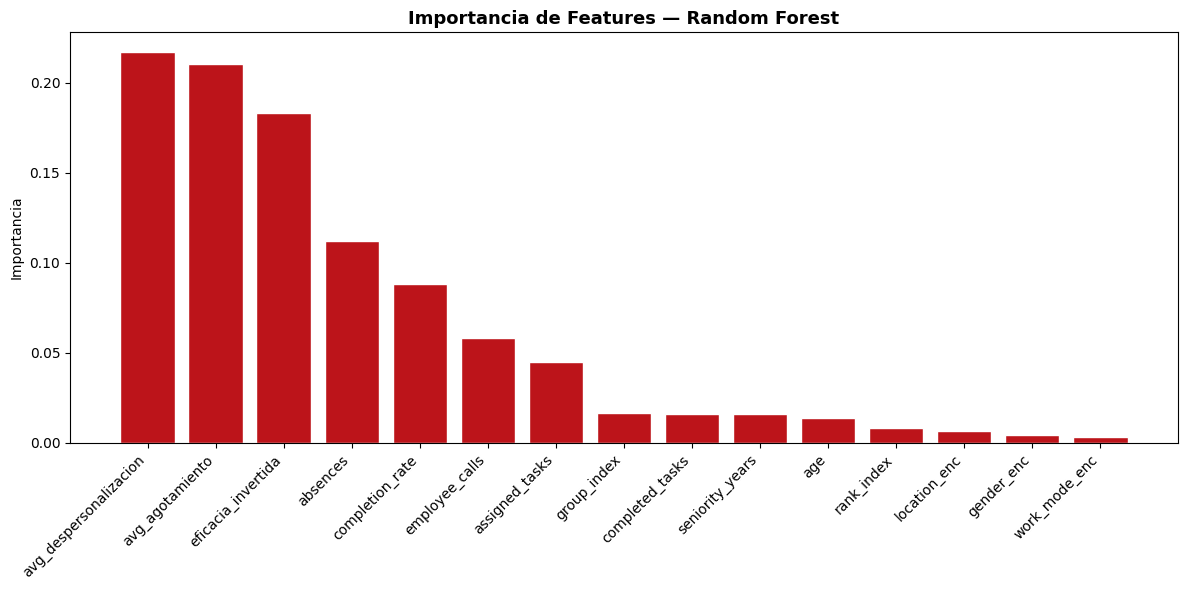

               Feature  Importancia
avg_despersonalizacion       0.2172
       avg_agotamiento       0.2105
    eficacia_invertida       0.1833
              absences       0.1123
       completion_rate       0.0882
        employee_calls       0.0583
        assigned_tasks       0.0449
           group_index       0.0168
       completed_tasks       0.0162
       seniority_years       0.0159
                   age       0.0137
            rank_index       0.0083
          location_enc       0.0067
            gender_enc       0.0043
         work_mode_enc       0.0035


In [16]:
importances = rf.feature_importances_
feature_names = X.columns

# Ordenar de mayor a menor
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[indices], color="#bc141a", edgecolor="white")
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha="right")
plt.title("Importancia de Features — Random Forest", fontsize=13, fontweight="bold")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

# Tabla con valores exactos
importance_df = pd.DataFrame({
    "Feature": [feature_names[i] for i in indices],
    "Importancia": importances[indices].round(4)
})
print(importance_df.to_string(index=False))

El modelo confirma que las variables psicométricas del MBI-GS (despersonalización, agotamiento y eficacia invertida) son los predictores más fuertes del burnout, seguidas por indicadores laborales objetivos como ausentismo, cantidad de tareas asginadas y tasa de completitud de tareas. Variables demográficas como género y ubicación tienen impacto mínimo, lo que descarta sesgos discriminatorios en el modelo.

### 10. Probabilidades de Predicción
Probabilidad de cada categoría para un empleado específico.


Probabilidades por empleado (primeros 5):
 Alto  Bajo  Medio  Moderado  Muy Bajo prediccion  confianza riesgo_real
 0.00  0.01   0.94      0.05       0.0      Medio       0.94       Medio
 0.00  0.09   0.91      0.00       0.0      Medio       0.91       Medio
 0.04  0.00   0.01      0.95       0.0   Moderado       0.95    Moderado
 0.99  0.00   0.00      0.01       0.0       Alto       0.99        Alto
 1.00  0.00   0.00      0.00       0.0       Alto       1.00        Alto


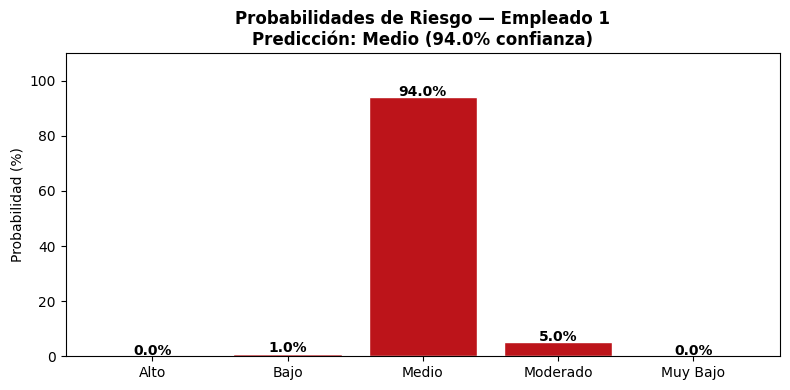

In [17]:
# Ejemplo: probabilidades para los empleados del test
probs = rf.predict_proba(X_test)

print("\nProbabilidades por empleado (primeros 5):")
prob_df = pd.DataFrame(probs, columns=rf.classes_)
prob_df["prediccion"] = rf.predict(X_test)
prob_df["confianza"] = probs.max(axis=1).round(4)
prob_df["riesgo_real"] = y_test.values

# Visualizar solo los 5 primeros empleados del test
print(prob_df.head(5).to_string(index=False))

# Visualización de probabilidades para un empleado específico
empleado_idx = 0  # cambia este número para ver otros empleados
probs_empleado = probs[empleado_idx]

plt.figure(figsize=(8, 4))
bars = plt.bar(rf.classes_, probs_empleado * 100, 
               color="#bc141a",
               edgecolor="white")
for bar, val in zip(bars, probs_empleado * 100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")

plt.title(f"Probabilidades de Riesgo — Empleado {empleado_idx+1}\nPredicción: {prob_df['prediccion'].iloc[empleado_idx]} ({prob_df['confianza'].iloc[empleado_idx]*100:.1f}% confianza)", 
          fontsize=12, fontweight="bold")
plt.ylabel("Probabilidad (%)")
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

### 11. Exportar el Modelo
Guardar el modelo entrenado en un archivo .pkl

In [18]:
import pickle
import os

# En caso de querer exportar el modelo en otra carpeta, se puede cambiar esta variable
path = "modelo_exportado"

# Crear carpeta si no existe
os.makedirs(path, exist_ok=True)

# Guardar el modelo Random Forest
with open(f"{path}/random_forest_burnout.pkl", "wb") as f:
    pickle.dump(rf, f)

# Guardar el orden de features (importante para que el backend arme el vector correctamente)
with open(f"{path}/features.pkl", "wb") as f:
    pickle.dump(FEATURES, f)

print("Modelo exportado correctamente")
print(f"Archivos guardados en: {path}/")
print(f"   - random_forest_burnout.pkl")
print(f"   - features.pkl")

# Verificar que carga correctamente
with open(f"{path}/random_forest_burnout.pkl", "rb") as f:
    modelo_cargado = pickle.load(f)

prueba = modelo_cargado.predict(X_test[:5])
print(f"\n Verificación — predicciones de prueba: {list(prueba)}")

Modelo exportado correctamente
Archivos guardados en: modelo_exportado/
   - random_forest_burnout.pkl
   - features.pkl

 Verificación — predicciones de prueba: ['Medio', 'Medio', 'Moderado', 'Alto', 'Alto']


Se exporta el modelo para que pueda ser usado sin necesidad de reentrenar, el backend lo carga y llama predict(). Se utiliza .pkl (pickle) ya que permite serializar objetos. 
La verificación con las predicciones de prueba, cumplen con las predicciones que se habían obtenido.